# **Credit Risk Scoring**

# 1. Introduction

The objective of this project is to develop a machine learning model to estimate the **Probability of Default (PD)** of credit card clients and transform this probability into an interpretable **credit score**.

Two models will be compared:

- Logistic Regression, as a traditional and interpretable credit risk model;
- XGBoost, as a more flexible machine learning approach for tabular data.


# 2. Data Understanding

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
plt.style.use('ggplot')

In [201]:
credit_data = fetch_ucirepo(id=350)

X = credit_data.data.features.copy()
y = credit_data.data.targets.copy()

df_og = pd.concat([X, y], axis=1)

In [202]:
df= df_og.copy()
df.shape

(30000, 24)

In [203]:
column_names = {
    "X1": "credit_limit",
    "X2": "sex",
    "X3": "education",
    "X4": "marital_status",
    "X5": "age",
    
    "X6": "payment_status_sep",
    "X7": "payment_status_aug",
    "X8": "payment_status_jul",
    "X9": "payment_status_jun",
    "X10": "payment_status_may",
    "X11": "payment_status_apr",
    
    "X12": "bill_amount_sep",
    "X13": "bill_amount_aug",
    "X14": "bill_amount_jul",
    "X15": "bill_amount_jun",
    "X16": "bill_amount_may",
    "X17": "bill_amount_apr",
    
    "X18": "payment_amount_sep",
    "X19": "payment_amount_aug",
    "X20": "payment_amount_jul",
    "X21": "payment_amount_jun",
    "X22": "payment_amount_may",
    "X23": "payment_amount_apr",
    
    "Y": "default"
}

In [204]:
df = df.rename(columns=column_names)

df.head()

,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,payment_status_apr,bill_amount_sep,bill_amount_aug,bill_amount_jul,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [205]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 30,000
Columns: 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   credit_limit        30000 non-null  int64
 1   sex                 30000 non-null  int64
 2   education           30000 non-null  int64
 3   marital_status      30000 non-null  int64
 4   age                 30000 non-null  int64
 5   payment_status_sep  30000 non-null  int64
 6   payment_status_aug  30000 non-null  int64
 7   payment_status_jul  30000 non-null  int64
 8   payment_status_jun  30000 non-null  int64
 9   payment_status_may  30000 non-null  int64
 10  payment_status_apr  30000 non-null  int64
 11  bill_amount_sep     30000 non-null  int64
 12  bill_amount_aug     30000 non-null  int64
 13  bill_amount_jul     30000 non-null  int64
 14  bill_amount_jun     30000 non-null  int64
 15  bill_amount_may     30000 non-null  int64
 16  bill_amount_apr

In [206]:
df.isna().sum().value_counts()

0    24
Name: count, dtype: int64

Duplicates

In [207]:
df.duplicated().sum()

35

In [208]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(6)

,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,payment_status_apr,bill_amount_sep,bill_amount_aug,bill_amount_jul,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default
12430,20000,1,2,2,24,2,2,4,4,4,4,1650,1650,1650,1650,1650,1650,0,0,0,0,0,0,1
14294,20000,1,2,2,24,2,2,4,4,4,4,1650,1650,1650,1650,1650,1650,0,0,0,0,0,0,1
1759,50000,1,2,2,26,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
10250,50000,1,2,2,26,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
7170,50000,2,1,2,23,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
17032,50000,2,1,2,23,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0


It is not clear if the index stands for an ID. I am inclined to agree that it does not, as it is sorted from 1 to 30000 just like a regular index. Let's proceed by checking if these entries are exact duplicates, which means that the target itself would assume the same value as the 'original entries' on the duplicates. If this happens to occur, I believe we have substantial evidence to remove the duplicates.

In [209]:
df_og.duplicated().sum()

35

In [210]:
df.drop_duplicates(inplace=True)

35 exact duplicate observations were identified and removed. Since the dataset does not provide a meaningful customer identifier to confirm that these records correspond to distinct clients, duplicates were treated as repeated observations.

In [211]:
for col in ["sex", "education", "marital_status"]:
    print(df[col].value_counts().sort_index())

sex
1    11874
2    18091
Name: count, dtype: int64
education
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64
marital_status
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64


In [212]:
df["default"].value_counts()

default
0    23335
1     6630
Name: count, dtype: int64

In [213]:
df["default"].value_counts(normalize=True)

default
0    0.778742
1    0.221258
Name: proportion, dtype: float64

In [214]:
# Group undocumented categories into "Others"
df["education"] = df["education"].replace({
    0: 4,
    5: 4,
    6: 4
})

df["marital_status"] = df["marital_status"].replace({
    0: 3
})

In [215]:
for col in ["sex", "education", "marital_status"]:
    print(df[col].value_counts().sort_index())

sex
1    11874
2    18091
Name: count, dtype: int64
education
1    10563
2    14019
3     4915
4      468
Name: count, dtype: int64
marital_status
1    13643
2    15945
3      377
Name: count, dtype: int64


In [216]:
sex_labels = {
    1: "Male",
    2: "Female"
}

education_labels = {
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Other"
}

marital_labels = {
    1: "Married",
    2: "Single",
    3: "Other"
}

In [217]:
payment_status_cols = [
    "payment_status_sep",
    "payment_status_aug",
    "payment_status_jul",
    "payment_status_jun",
    "payment_status_may",
    "payment_status_apr"
]

for col in payment_status_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


payment_status_sep
payment_status_sep
-2     2750
-1     5682
 0    14737
 1     3667
 2     2666
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

payment_status_aug
payment_status_aug
-2     3752
-1     6046
 0    15730
 1       28
 2     3926
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

payment_status_jul
payment_status_jul
-2     4055
-1     5934
 0    15764
 1        4
 2     3819
 3      240
 4       75
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

payment_status_jun
payment_status_jun
-2     4318
-1     5683
 0    16455
 1        2
 2     3159
 3      180
 4       68
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

payment_status_may
payment_status_may
-2     4516
-1     5535
 0    16947
 2     2626
 3      178
 4       83
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

payment_status_apr
payment

Repayment status:

- -2: no consumption

- -1: paid duly

- 0: revolving credit

- 1–8:  number of months of payment delay

# 3. Exploratory Data Analysis

In [218]:
df.head()

,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,payment_status_apr,bill_amount_sep,bill_amount_aug,bill_amount_jul,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3.1 Target Distribution

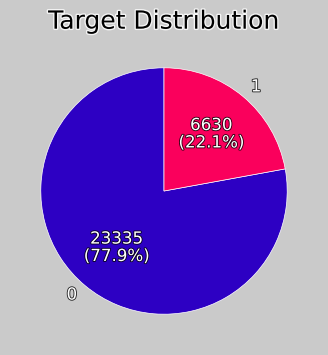

In [219]:
import matplotlib.patheffects as path_effects 

target_counts = df['default'].value_counts()

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val}\n({pct:.1f}%)' 
    return my_autopct

fig, ax = plt.subplots(figsize=(5, 5))

ax = target_counts.plot.pie(
    autopct=make_autopct(target_counts),
    startangle=90, 
    figsize=(4, 4),
    colors=["#2D00C3", "#FA005C"],
    textprops={'fontsize': 12, 'color': 'white'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5}, 
)

for text in ax.texts:
    text.set_path_effects([
        path_effects.withStroke(linewidth=1.3, foreground='black', alpha=0.8)
    ])

fig.patch.set_facecolor("#CACACA") 
ax.set_facecolor('#CACACA')

title = plt.title('Target Distribution', color='black', fontsize=18)
title.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white', alpha=0.8)])
plt.ylabel('')
plt.show()

In [220]:
df['default'].value_counts(normalize=True).round(3)

default
0    0.779
1    0.221
Name: proportion, dtype: float64

Approximately 22% of clients defaulted on their credit card payments. Although the target is moderately imbalanced, the minority class is sufficiently represented to train and evaluate classification models without applying resampling techniques initially.

## 3.2 - Default Rate by Most Recent Repayment Status

In [221]:
payment_default_rate = (
    df.groupby("payment_status_sep")["default"]
      .agg(["count", "mean"])
      .reset_index()
)

# payment_default_rate

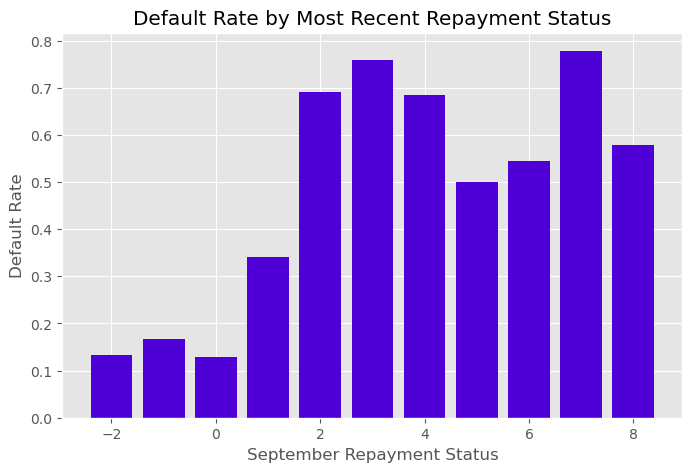

In [222]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    payment_default_rate["payment_status_sep"],
    payment_default_rate["mean"],
    color="#4f00d6"
)

ax.set_xlabel("September Repayment Status")
ax.set_ylabel("Default Rate")
ax.set_title("Default Rate by Most Recent Repayment Status")

plt.show()

## 3.3 Default Rate Across Six Months

In [223]:
payment_status_cols = [
    "payment_status_sep",
    "payment_status_aug",
    "payment_status_jul",
    "payment_status_jun",
    "payment_status_may",
    "payment_status_apr"
]

months = ["Sep", "Aug", "Jul", "Jun", "May", "Apr"]

payment_rates = []

for col, month in zip(payment_status_cols, months):
    temp = (
        df.groupby(col)["default"]
          .mean()
          .reset_index()
    )
    
    temp.columns = ["payment_status", "default_rate"]
    temp["month"] = month
    
    payment_rates.append(temp)

payment_rates = pd.concat(payment_rates, ignore_index=True)

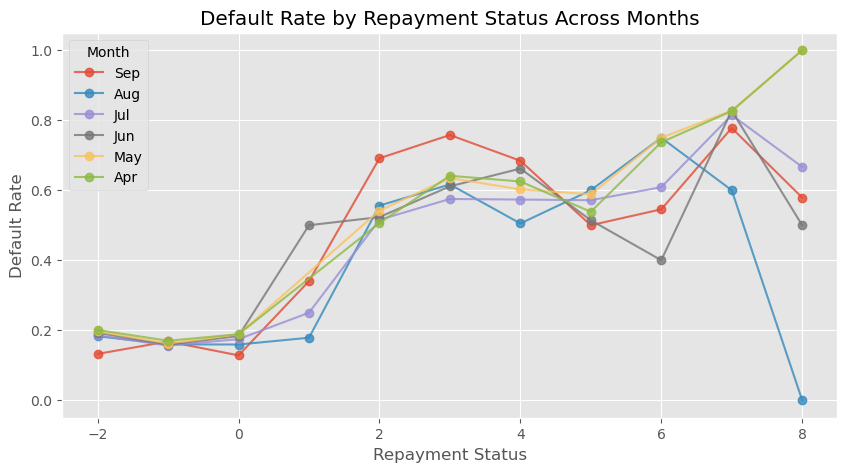

In [224]:
fig, ax = plt.subplots(figsize=(10, 5))

for month in months:
    temp = payment_rates[payment_rates["month"] == month]
    
    ax.plot(
        temp["payment_status"],
        temp["default_rate"],
        marker="o",
        label=month,
        alpha=0.8,
    )

ax.set_title("Default Rate by Repayment Status Across Months")
ax.set_xlabel("Repayment Status")
ax.set_ylabel("Default Rate")
ax.legend(title="Month")

plt.show()

## 3.4 Credit Limit vs Default

In [225]:
df.groupby("default")["credit_limit"].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,23335.0,178084.508249,131665.894718,10000.0,70000.0,150000.0,250000.0,1000000.0
1,6630.0,129984.567119,115258.618215,10000.0,50000.0,90000.0,200000.0,740000.0


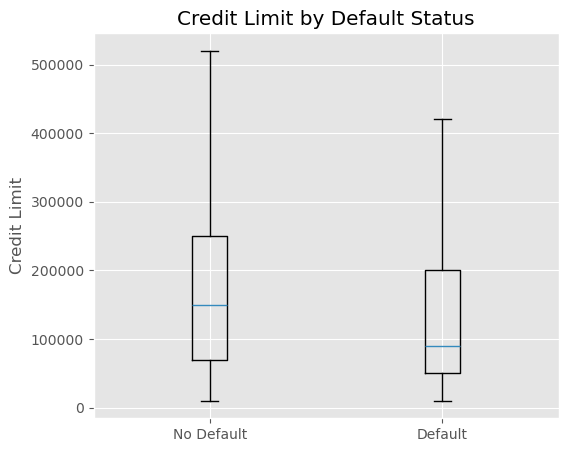

In [226]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.boxplot(
    [
        df.loc[df["default"] == 0, "credit_limit"],
        df.loc[df["default"] == 1, "credit_limit"]
    ],
    labels=["No Default", "Default"],
    showfliers=False
)

ax.set_title("Credit Limit by Default Status")
ax.set_ylabel("Credit Limit")

plt.show()

Clients who defaulted tend to have lower credit limits. However, this relationship should be interpreted as an association rather than a causal effect, since credit limits are themselves influenced by the financial profile of each client.

## 3.5 Age vs Default

In [227]:
age_bins = [20, 30, 40, 50, 60, 70, 100]
age_labels = [
    "20–29",
    "30–39",
    "40–49",
    "50–59",
    "60–69",
    "70+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

In [228]:
age_default_rate = (
    df.groupby("age_group", observed=False)["default"]
      .agg(["count", "mean"])
      .reset_index()
)

# age_default_rate

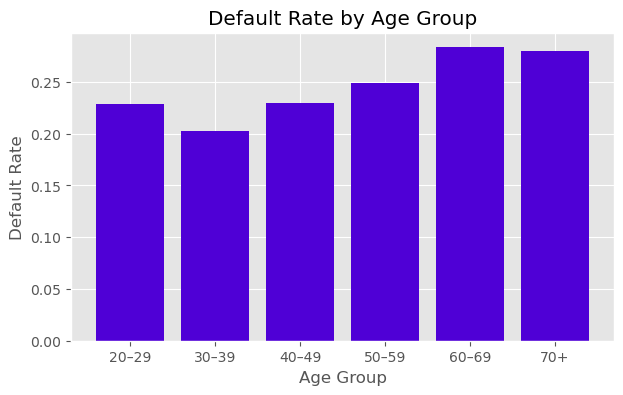

In [229]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    age_default_rate["age_group"].astype(str),
    age_default_rate["mean"],
    color="#4f00d6"
)

ax.set_title("Default Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Default Rate")

plt.show()

In [230]:
df = df.drop(columns="age_group")

## 3.6 Payment Ratio

$$
\text{Payment Ratio} =
\frac{\text{Payment Amount}}{\text{Bill Amount}}
$$

In [231]:
positive_bill = df["bill_amount_sep"] > 0

df.loc[positive_bill].assign(
    payment_ratio=lambda x:
        x["payment_amount_sep"] / x["bill_amount_sep"]
).groupby("default")["payment_ratio"].median()

default
0    0.065843
1    0.050262
Name: payment_ratio, dtype: float64

In [232]:
eda_payment = df.loc[df["bill_amount_sep"] > 0].copy()

eda_payment["payment_ratio"] = (
    eda_payment["payment_amount_sep"] /
    eda_payment["bill_amount_sep"]
)

eda_payment["payment_ratio"] = eda_payment["payment_ratio"].clip(0, 2)

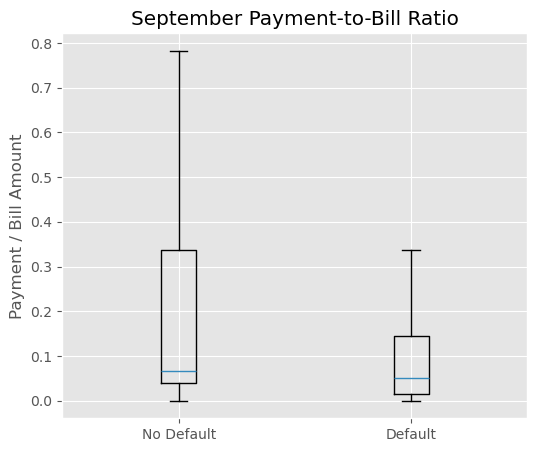

In [233]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.boxplot(
    [
        eda_payment.loc[
            eda_payment["default"] == 0,
            "payment_ratio"
        ],
        eda_payment.loc[
            eda_payment["default"] == 1,
            "payment_ratio"
        ]
    ],
    labels=["No Default", "Default"],
    showfliers=False
)

ax.set_title("September Payment-to-Bill Ratio")
ax.set_ylabel("Payment / Bill Amount")

plt.show()

## 3.7 Correlation

In [234]:
numeric_corr = df.corr(numeric_only=True)["default"] \
    .drop("default") \
    .sort_values()

In [235]:
pd.concat([
    numeric_corr.head(8),
    numeric_corr.tail(8)
])

credit_limit         -0.153871
payment_amount_sep   -0.073015
payment_amount_aug   -0.058643
payment_amount_jun   -0.056898
payment_amount_jul   -0.056319
payment_amount_may   -0.055194
payment_amount_apr   -0.053250
sex                  -0.039742
age                   0.013619
education             0.033862
payment_status_apr    0.186740
payment_status_may    0.204059
payment_status_jun    0.216551
payment_status_jul    0.235230
payment_status_aug    0.263656
payment_status_sep    0.324964
Name: default, dtype: float64

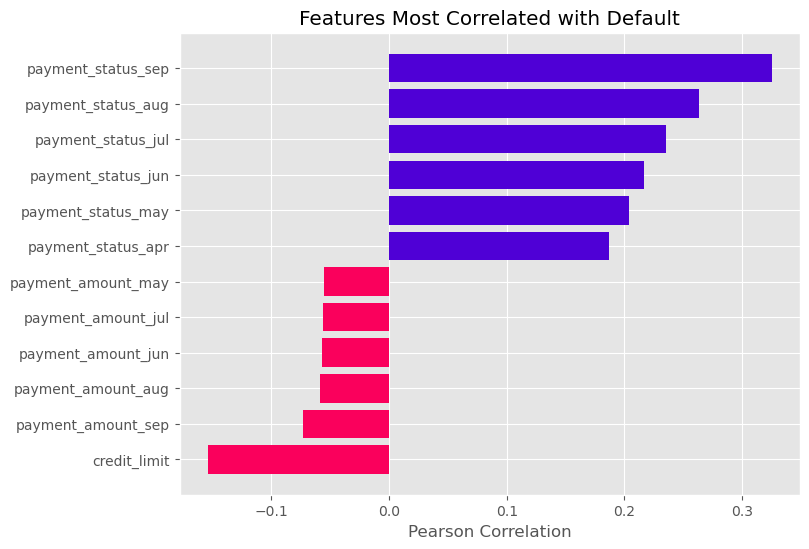

In [236]:
top_corr = pd.concat([
    numeric_corr.head(6),
    numeric_corr.tail(6)
]).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    top_corr.index,
    top_corr.values,
    color=np.where(top_corr.values > 0, "#4f00d6", "#FA005C")
)

ax.set_title("Features Most Correlated with Default")
ax.set_xlabel("Pearson Correlation")

plt.show()

All the numeric features showed 0.33 or less Person Correlation coefficients. This means that they share weak relationships with the target.

## 3.8 Summary

The exploratory analysis indicates that repayment behavior is strongly associated with credit default. Clients with recent payment delays present substantially higher default rates, making repayment status variables particularly relevant predictors. Defaulted clients also tend to have lower credit limits and lower payment-to-bill ratios. Demographic variables such as age appear to have weaker relationships with default compared with recent financial behavior.

These results suggest that payment history and recent credit utilization behavior should play an important role in the predictive models.

# 4. Data Processing

## 4.1 Target and Features

In [237]:
X = df.drop(columns="default")
y = df["default"]

## 4.2 Train-test Split

In [238]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=1,
)

# print("Train:", X_train.shape)
# print("Test:", X_test.shape)

# print("\nTrain target distribution:")
# print(y_train.value_counts(normalize=True))

# print("\nTest target distribution:")
# print(y_test.value_counts(normalize=True))

The dataset was divided into 80% training and 20% testing sets using stratified sampling to preserve the original default rate in both subsets.

## 4.3 Feature Types

In [239]:
categorical_features = [
    "sex",
    "education",
    "marital_status",
    "payment_status_sep",
    "payment_status_aug",
    "payment_status_jul",
    "payment_status_jun",
    "payment_status_may",
    "payment_status_apr"
]

numerical_features = [
    "credit_limit",
    "age",
    "bill_amount_sep",
    "bill_amount_aug",
    "bill_amount_jul",
    "bill_amount_jun",
    "bill_amount_may",
    "bill_amount_apr",
    "payment_amount_sep",
    "payment_amount_aug",
    "payment_amount_jul",
    "payment_amount_jun",
    "payment_amount_may",
    "payment_amount_apr"
]

## 4.4 Data Preprocessing

### 4.4.1 Logistic Regression

In [240]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ("numerical", StandardScaler(), numerical_features)
    ]
)

### 4.4.2 XGBoost

In [241]:
xgb_preprocessor= ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numerical', "passthrough", numerical_features)
        ]
)

- Categorical variables were encoded using One-Hot Encoding. The repayment status variables were also treated as categorical features because their codes represent distinct financial states rather than a strictly linear numerical scale.

- For Logistic Regression, continuous variables were standardized using StandardScaler, since the features have substantially different scales. XGBoost does not require feature scaling, so numerical variables were kept in their original scale.

# 5. Logistic Regression

Logistic Regression will be used as the baseline model due to its widespread use in traditional credit risk modeling and its interpretability.

The model estimates the probability that a client will default:

$$
P(Y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1X_1 + \cdots + \beta_pX_p)}}
$$

## 5.1 Build and Training

In [242]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("classifier", LogisticRegression(random_state=1, max_iter=1000))
])

In [243]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'education',
                                                   'marital_status',
                                                   'payment_status_sep',
                                                   'payment_status_aug',
                                                   'payment_status_jul',
                                                   'payment_status_jun',
                                                   'payment_status_may',
                                                   'payment_status_apr']),
                                                 ('numerical', StandardScaler(),
                                                  ['credit_limit', 'age',
                                                   'bill_amount_sep',
                                                   'bill_amount_aug',
                                                   'bill_amount_jul',
                                                   'bill_amount_jun',
                                                   'bill_amount_may',
                                                   'bill_amount_apr',
                                                   'payment_amount_sep',
                                                   'payment_amount_aug',
                                                   'payment_amount_jul',
                                                   'payment_amount_jun',
                                                   'payment_amount_may',
                                                   'payment_amount_apr'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=1))])

Continuous features were standardized and categorical variables were encoded using One-Hot Encoding.

## 5.2 Prediction and Results

In [244]:
y_pred_log = logistic_model.predict(X_test)

y_proba_log = logistic_model.predict_proba(X_test)[:, 1]

In [245]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def model_evaluation(y_test, y_pred, y_prob):
    result = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob)
    }
    return result

def plot_confusion_matrix(y_test, y_pred, size=(5, 4), title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=size)

    ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Default", "Default"],
    cmap='Blues',
    ax=ax
)

    plt.title(f"{title}")
    plt.show()

In [246]:
logistic_results = model_evaluation(y_test,y_pred_log, y_proba_log)
pd.Series(logistic_results).round(4)

Accuracy     0.8190
Precision    0.6676
Recall       0.3620
F1           0.4694
ROC-AUC      0.7689
PR-AUC       0.5411
dtype: float64

Model performance was evaluated using ROC-AUC, PR-AUC, precision, recall and F1-score. The predicted probabilities will later be used to construct the credit score.

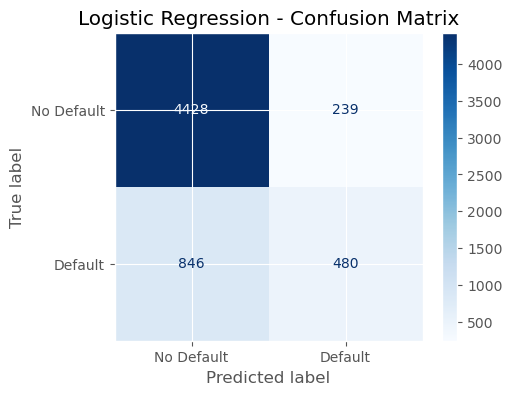

In [247]:
plot_confusion_matrix(y_test, y_pred_log, size=(5, 4), title="Logistic Regression - Confusion Matrix")

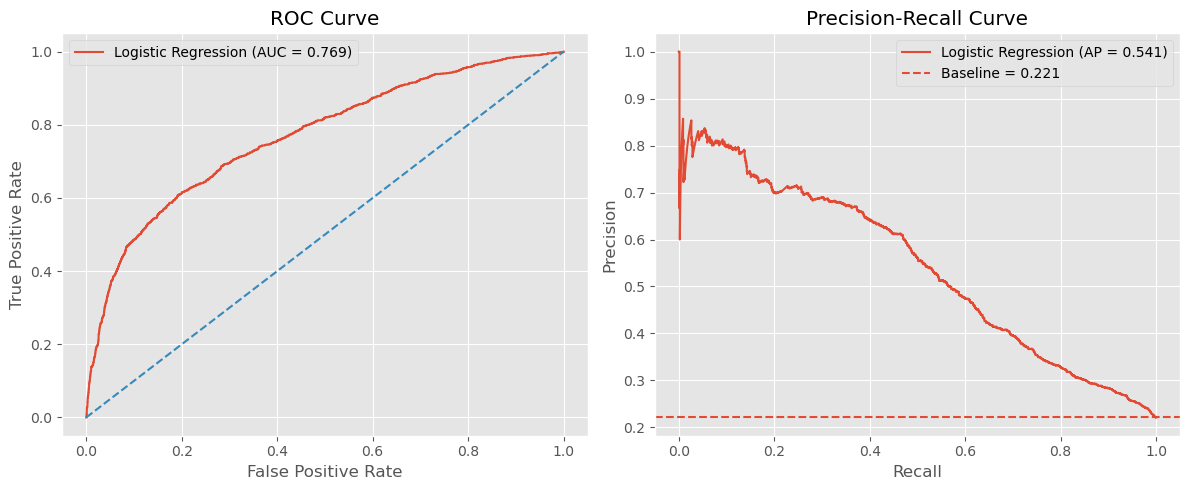

In [248]:
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)

# Precision-Recall curve
precision_log, recall_log, _ = precision_recall_curve(
    y_test,
    y_proba_log
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {logistic_results['ROC-AUC']:.3f})"
)

axes[0].plot([0, 1], [0, 1], linestyle="--")

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall Curve
axes[1].plot(
    recall_log,
    precision_log,
    label=f"Logistic Regression (AP = {logistic_results['PR-AUC']:.3f})"
)

axes[1].axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Baseline = {y_test.mean():.3f}"
)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

In [249]:
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient")

# coef_df

In [250]:
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

coef_df["feature"] = (
    coef_df["feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
)

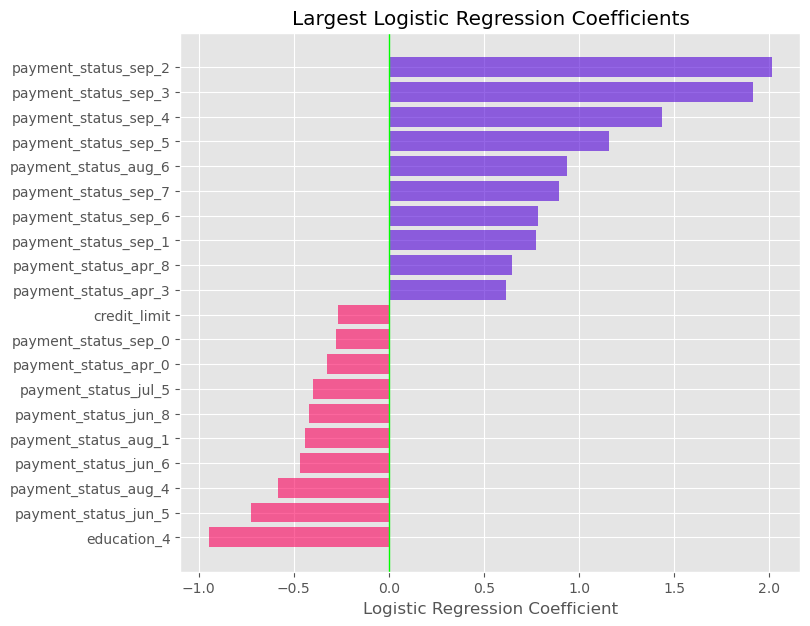

In [251]:
important_coef = pd.concat([
    coef_df.head(10),
    coef_df.tail(10)
])

fig, ax = plt.subplots(figsize=(8, 7))

ax.barh(
    important_coef["feature"],
    important_coef["coefficient"],
    color=np.where(important_coef["coefficient"] > 0, "#4f00d6", "#FA005C"),
    alpha=0.6
)

ax.axvline(0, linewidth=1, color='lime')

ax.set_xlabel("Logistic Regression Coefficient")
ax.set_title("Largest Logistic Regression Coefficients")

plt.show()

Logistic Regression showed good discriminatory performance, achieving a ROC-AUC of 0.769 and a PR-AUC of 0.541, substantially above the default prevalence baseline of 0.221. Recent repayment status emerged as one of the strongest predictors of default. Although classification recall at the standard 0.5 threshold was relatively low, the model provides a useful baseline for ranking clients according to their estimated probability of default.

# 6. XGBoost

## 6.1 Baseline Model

In [252]:
from xgboost import XGBClassifier

xgb_model= Pipeline([
    ("preprocessor", xgb_preprocessor),
    ("classifier", XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=1,
        n_jobs=1
        ))
])

In [253]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'education',
                                                   'marital_status',
                                                   'payment_status_sep',
                                                   'payment_status_aug',
                                                   'payment_status_jul',
                                                   'payment_status_jun',
                                                   'payment_status_may',
                                                   'payment_status_apr']),
                                                 ('numerical', 'passthrough',
                                                  ['credit_limit', 'age',
                                                   'bill_amount_sep',
                                                   '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=1,
                               num_parallel_tree=None, ...))])

In [254]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [255]:
xgb_results = model_evaluation(y_test, y_pred_xgb, y_proba_xgb)
pd.Series(xgb_results).round(4)

Accuracy     0.8123
Precision    0.6290
Recall       0.3695
F1           0.4656
ROC-AUC      0.7644
PR-AUC       0.5258
dtype: float64

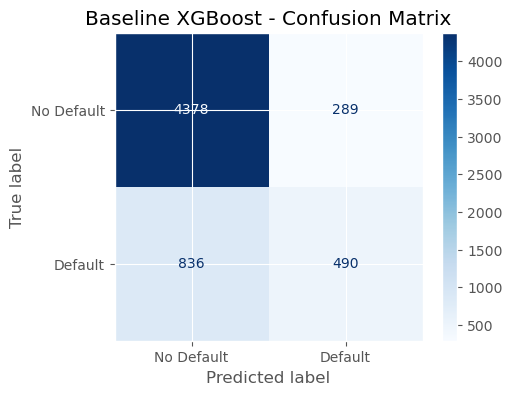

In [256]:
plot_confusion_matrix(y_test, y_pred_xgb, title='Baseline XGBoost - Confusion Matrix')

### Comparison

In [257]:
baseline_comparison = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "XGBoost": xgb_results
}).T

baseline_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.8190,0.6676,0.3620,0.4694,0.7689,0.5411
XGBoost,0.8123,0.6290,0.3695,0.4656,0.7644,0.5258


## 6.2 Hyperparameter Tuning

In [258]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "classifier__n_estimators": [200, 300, 400, 500],
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5, 10],
    "classifier__gamma": [0, 0.1, 0.3],
    "classifier__reg_alpha": [0, 0.01, 0.1],
    "classifier__reg_lambda": [0.5, 1, 2]
}

In [259]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=25,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    random_state=1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('categorical',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['sex',
                                                                                'education',
                                                                                'marital_status',
                                                                                'payment_status_sep',
                                                                                'payment_status_aug',
                                                                                'payment_status_jul',
                                                                                'payment_status_jun',
                                                                                'payment_status_may',
                                                                                'payment_status_apr']),
                                                                              ('numerical',
                                                                               'passthrough',
                                                                               ['credi...
                                        'classifier__gamma': [0, 0.1, 0.3],
                                        'classifier__learning_rate': [0.01,
                                                                      0.03,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [3, 4, 5, 6],
                                        'classifier__min_child_weight': [1, 3,
                                                                         5,
                                                                         10],
                                        'classifier__n_estimators': [200, 300,
                                                                     400, 500],
                                        'classifier__reg_alpha': [0, 0.01, 0.1],
                                        'classifier__reg_lambda': [0.5, 1, 2],
                                        'classifier__subsample': [0.7, 0.8, 0.9,
                                                                  1.0]},
                   random_state=1, scoring='average_precision', verbose=1)

In [260]:
print(f"Best CV PR-AUC: {xgb_search.best_score_:.4f}")

print("\nBest parameters:")
xgb_search.best_params_

Best CV PR-AUC: 0.5660

Best parameters:


{'classifier__subsample': 0.8,
 'classifier__reg_lambda': 1,
 'classifier__reg_alpha': 0,
 'classifier__n_estimators': 400,
 'classifier__min_child_weight': 3,
 'classifier__max_depth': 6,
 'classifier__learning_rate': 0.01,
 'classifier__gamma': 0,
 'classifier__colsample_bytree': 0.9}

## 6.3 Best Model

In [261]:
best_xgb = xgb_search.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)

y_proba_xgb_tuned = best_xgb.predict_proba(
    X_test
)[:, 1]

In [262]:
xgb_tuned_results = model_evaluation(y_test, y_pred_xgb_tuned, y_proba_xgb_tuned)
pd.Series(xgb_tuned_results).round(4)

Accuracy     0.8195
Precision    0.6743
Recall       0.3560
F1           0.4659
ROC-AUC      0.7903
PR-AUC       0.5584
dtype: float64

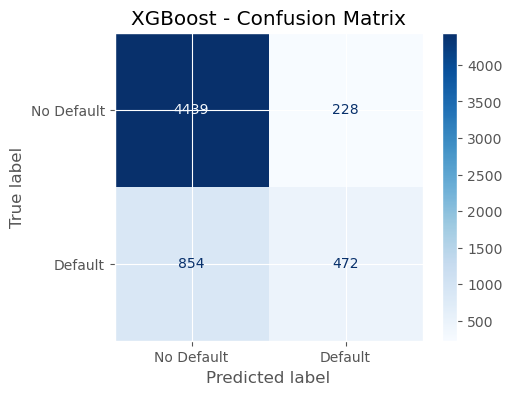

In [263]:
plot_confusion_matrix(y_test, y_pred_xgb_tuned, title='XGBoost - Confusion Matrix')

# 7. Model Comparison

In [264]:
model_comparison = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "XGBoost Baseline": xgb_results,
    "XGBoost Tuned": xgb_tuned_results
}).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.8190,0.6676,0.3620,0.4694,0.7689,0.5411
XGBoost Baseline,0.8123,0.6290,0.3695,0.4656,0.7644,0.5258
XGBoost Tuned,0.8195,0.6743,0.3560,0.4659,0.7903,0.5584


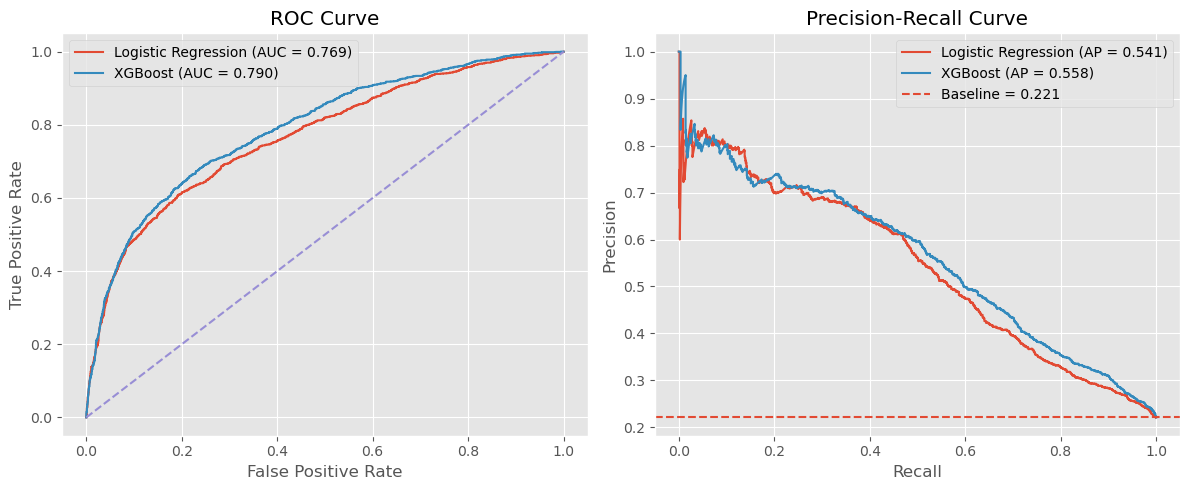

In [265]:
# ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb_tuned)

# Precision-Recall
precision_log, recall_log, _ = precision_recall_curve(
    y_test, y_proba_log
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test, y_proba_xgb_tuned
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# ROC Curve
axes[0].plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {logistic_results['ROC-AUC']:.3f})"
)

axes[0].plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {xgb_tuned_results['ROC-AUC']:.3f})"
)

axes[0].plot([0, 1], [0, 1], linestyle="--")

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()


# Precision-Recall Curve
axes[1].plot(
    recall_log,
    precision_log,
    label=f"Logistic Regression (AP = {logistic_results['PR-AUC']:.3f})"
)

axes[1].plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost (AP = {xgb_tuned_results['PR-AUC']:.3f})"
)

axes[1].axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Baseline = {y_test.mean():.3f}"
)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## Calibration Score

In [266]:
from sklearn.metrics import brier_score_loss

brier_log = brier_score_loss(y_test, y_proba_log)
brier_xgb = brier_score_loss(y_test, y_proba_xgb_tuned)

print(f"Logistic Regression Brier Score: {brier_log:.4f}")
print(f"XGBoost Brier Score:            {brier_xgb:.4f}")

Logistic Regression Brier Score: 0.1367
XGBoost Brier Score:            0.1334


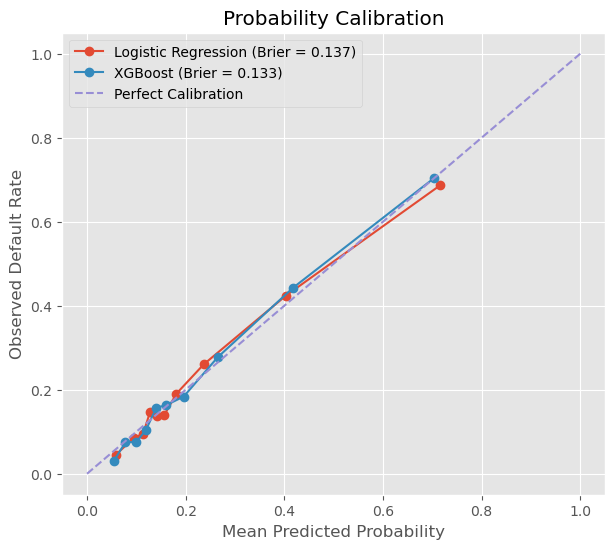

In [267]:
from sklearn.calibration import calibration_curve

prob_true_log, prob_pred_log = calibration_curve(
    y_test,
    y_proba_log,
    n_bins=10,
    strategy="quantile"
)

prob_true_xgb, prob_pred_xgb = calibration_curve(
    y_test,
    y_proba_xgb_tuned,
    n_bins=10,
    strategy="quantile"
)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    prob_pred_log,
    prob_true_log,
    marker="o",
    label=f"Logistic Regression (Brier = {brier_log:.3f})"
)

ax.plot(
    prob_pred_xgb,
    prob_true_xgb,
    marker="o",
    label=f"XGBoost (Brier = {brier_xgb:.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Default Rate")
ax.set_title("Probability Calibration")
ax.legend()

plt.show()

# 8. Credit Score

The final XGBoost model produces an estimated Probability of Default (PD) for each client. To make these probabilities easier to interpret, they are transformed into a credit score using an odds-based scaling approach.

The odds of a client not defaulting are defined as:

$$
\text{Odds(PD)} = \frac{1-PD}{PD}
$$


The credit score is then calculated as:

$$
\text{Score(PD)} =
\text{Offset}
+
\text{Factor}\cdot\ln(\text{Odds(PD)})
$$

where:

$$
\text{Factor} = \frac{PDO}{\ln(2)}
$$

and

$$
\text{Offset}
=
\text{Base Score}
-
\text{Factor}\ln(\text{Base Odds})
$$


In [268]:
BASE_SCORE = 600
PDO = 50

default_rate_train = y_train.mean()

BASE_ODDS = (1 - default_rate_train) / default_rate_train

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

print(f"Training default rate: {default_rate_train:.2%}")
print(f"Base odds: {BASE_ODDS:.2f}:1")
print(f"Factor: {factor:.2f}")
print(f"Offset: {offset:.2f}")

Training default rate: 22.13%
Base odds: 3.52:1
Factor: 72.13
Offset: 509.23


The score was anchored at 600 points using the average default odds observed in the training portfolio. Therefore, a score close to 600 represents approximately the average credit risk of the training population. The Points to Double the Odds (PDO) was set to 50, meaning that every doubling of the odds of non-default increases the score by 50 points.

The scaling parameters were chosen as convenient reference values for the credit score scale, resulting in a project-specific score that should not be interpreted as an official FICO or commercial credit score.

In [269]:
pd_default = np.clip(y_proba_xgb_tuned,1e-6,1 - 1e-6)

odds = (1 - pd_default) / pd_default

credit_score = (offset + factor * np.log(odds)).round().astype(int)

In [270]:
score_results = pd.DataFrame({
    "actual_default": y_test.values,
    "probability_of_default": pd_default,
    "credit_score": credit_score
})

score_results.head(10)

,actual_default,probability_of_default,credit_score
0,0,0.070643,695
1,0,0.261136,584
2,0,0.126569,649
3,0,0.063263,704
4,1,0.281297,577
5,1,0.213979,603
6,0,0.151082,634
7,0,0.282308,577
8,0,0.137354,642
9,0,0.386653,543


In [271]:
score_results["credit_score"].describe()

count    5993.000000
mean      616.731353
std        76.700127
min       340.000000
25%       583.000000
50%       635.000000
75%       668.000000
max       753.000000
Name: credit_score, dtype: float64

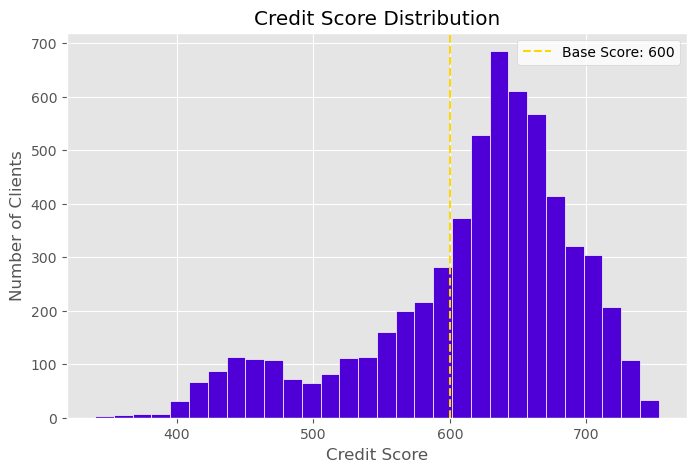

In [272]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    score_results["credit_score"],
    bins=30,
    edgecolor="white",
    color="#4f00d6"
)

ax.axvline(600, color='gold', linestyle="--", label="Base Score: 600")
ax.set_title("Credit Score Distribution")
ax.set_xlabel("Credit Score")
ax.set_ylabel("Number of Clients")
ax.legend(facecolor='white')

plt.show()

In [273]:
score_results["score_decile"] = pd.qcut(
    score_results["credit_score"],
    q=10,
    duplicates="drop"
)

score_analysis = (
    score_results
    .groupby("score_decile", observed=False)
    .agg(
        clients=("actual_default", "size"),
        avg_score=("credit_score", "mean"),
        avg_pd=("probability_of_default", "mean"),
        observed_default_rate=("actual_default", "mean")
    )
    .reset_index()
)

score_analysis

,score_decile,clients,avg_score,avg_pd,observed_default_rate
0,"(339.999, 489.2]",600,444.973333,0.703031,0.703333
1,"(489.2, 564.0]",613,534.473083,0.415059,0.435563
2,"(564.0, 600.0]",608,584.347039,0.261829,0.274671
3,"(600.0, 621.0]",577,611.755633,0.194793,0.185442
4,"(621.0, 635.0]",661,629.040847,0.159753,0.161876
5,"(635.0, 647.0]",589,641.348048,0.138173,0.159593
6,"(647.0, 660.0]",550,653.798182,0.118875,0.098182
7,"(660.0, 676.0]",607,668.029654,0.099794,0.077430
8,"(676.0, 700.0]",600,688.220000,0.077454,0.073333
9,"(700.0, 753.0]",588,717.047619,0.053717,0.028912


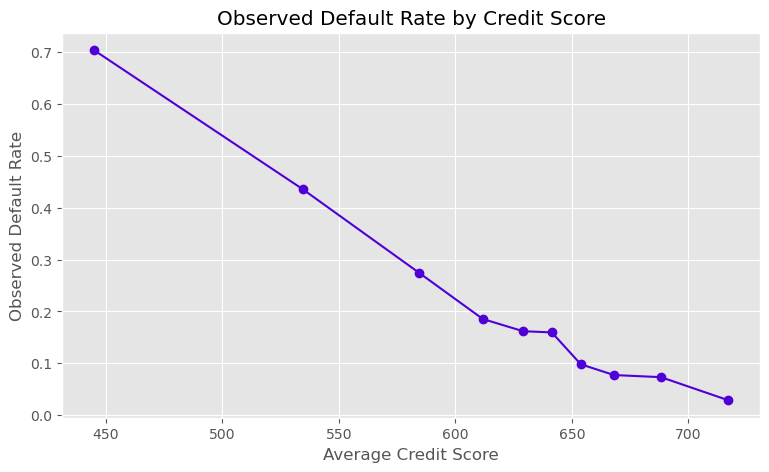

In [274]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    score_analysis["avg_score"],
    score_analysis["observed_default_rate"],
    marker="o",
    color='#4f00d6'
)

ax.set_title("Observed Default Rate by Credit Score")
ax.set_xlabel("Average Credit Score")
ax.set_ylabel("Observed Default Rate")

plt.show()

# 9. Risk Grades

In [275]:
risk_bins = [0, 0.05, 0.10, 0.20, 0.40, 1]

risk_labels = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

score_results["risk_grade"] = pd.cut(
    score_results["probability_of_default"],
    bins=risk_bins,
    labels=risk_labels,
    include_lowest=True,
    right=False
)

In [276]:
risk_summary = (
    score_results
    .groupby("risk_grade", observed=False)
    .agg(
        clients=("actual_default", "size"),
        avg_score=("credit_score", "mean"),
        avg_pd=("probability_of_default", "mean"),
        observed_default_rate=("actual_default", "mean")
    )
)
risk_summary

,clients,avg_score,avg_pd,observed_default_rate
risk_grade,,,,
Very Low,195,731.430769,0.044112,0.010256
Low,1297,690.960678,0.075820,0.066307
Moderate,2470,639.792308,0.142710,0.134413
High,1123,579.705254,0.276875,0.295637
Very High,908,469.129956,0.626066,0.632159


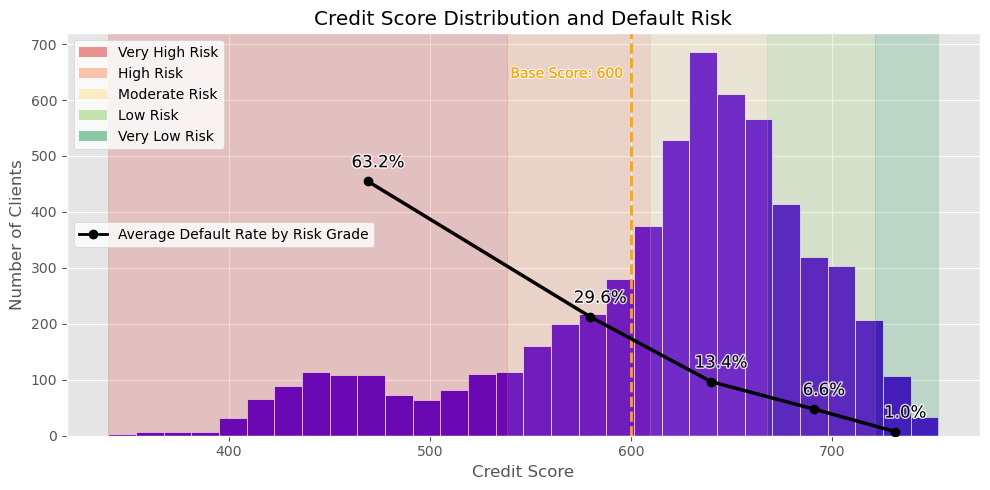

In [319]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

pd_thresholds = np.array([0.40, 0.20, 0.10, 0.05])

score_thresholds = (
    offset
    + factor * np.log((1 - pd_thresholds) / pd_thresholds)
)

score_40, score_20, score_10, score_05 = score_thresholds

x_min = score_results["credit_score"].min()
x_max = score_results["credit_score"].max()

boundaries = [
    x_min,
    score_40,
    score_20,
    score_10,
    score_05,
    x_max
]

risk_order = [
    "Very High",
    "High",
    "Moderate",
    "Low",
    "Very Low"
]

colors = [
    "#d73027",
    "#fc8d59",
    "#fee08b",
    "#91cf60",
    "#1a9850"
]

# Summary by risk grade
risk_summary = (
    score_results
    .groupby("risk_grade", observed=False)
    .agg(
        clients=("actual_default", "size"),
        avg_score=("credit_score", "mean"),
        observed_default_rate=("actual_default", "mean")
    )
    .reindex(risk_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

# Histogram
ax.hist(
    score_results["credit_score"],
    bins=30,
    edgecolor="white",
    color="#4f00d6"
)

# Risk grade regions
for left, right, color in zip(
    boundaries[:-1],
    boundaries[1:],
    colors
):
    ax.axvspan(
        left,
        right,
        color=color,
        alpha=0.2
    )

# Base score
ax.axvline(
    600,
    color="orange",
    linestyle="--",
    linewidth=2
)

ax.annotate('Base Score: 600', xy=(540, 640), color='orange').set_path_effects([path_effects.withStroke(linewidth=1.5, foreground='white', alpha=1), path_effects.withStroke(linewidth=0.05,foreground='black', alpha=0.1)])

ax.set_title("Credit Score Distribution and Default Risk")
ax.set_xlabel("Credit Score")
ax.set_ylabel("Number of Clients")

# Hidden secondary axis for default rate
ax2 = ax.twinx()

ax2.plot(
    risk_summary["avg_score"],
    risk_summary["observed_default_rate"],
    marker="o",
    linewidth=2.5,
    color="black"
)

# Fixed scale, but visually hidden
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.set_ylabel("")
ax2.grid(False)

ax2.tick_params(
    right=False,
    labelright=False
)

for spine in ax2.spines.values():
    spine.set_visible(False)

# Default rate labels
for _, row in risk_summary.iterrows():
    ax2.annotate(
        f"{row['observed_default_rate']:.1%}",
        xy=(
            row["avg_score"] + 5,
            row["observed_default_rate"]
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=12,
        # fontweight="bold",
        color="black"
    ).set_path_effects([path_effects.withStroke(linewidth=2, foreground='white', alpha=0.8)])

# Legend

legend_alt = ax.legend(
    handles=[
    Line2D(
        [0], [0],
        color="black",
        marker="o",
        linewidth=2,
        label="Average Default Rate by Risk Grade"
    )],
    facecolor='white',
    loc='center left'
)
ax.add_artist(legend_alt)


legend_elements = [
    *[
        Patch(
            facecolor=color,
            alpha=0.5,
            label=f"{risk} Risk"
        )
        for risk, color in zip(risk_order, colors)
    ]
]

ax.legend(
    handles=legend_elements,
    facecolor="white",
    loc="upper left",
    # title='Risk Grade'
)

plt.tight_layout()
plt.show()

To improve interpretability, clients were grouped into five risk categories based on their estimated Probability of Default.

The risk grades are project-specific and are intended only to provide an intuitive representation of the model predictions rather than reproduce the lending policies of any financial institution.

# 10. Model Explainability

## 10.1 Feature Importance

In [278]:
import shap
preprocessor = best_xgb.named_steps["preprocessor"]
xgb_classifier = best_xgb.named_steps["classifier"]

X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name
    .replace("categorical__", "")
    .replace("remainder__", "")
    for name in feature_names
]

In [309]:
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

X_test_shap.columns = (
    X_test_shap.columns
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
)

In [310]:
explainer = shap.TreeExplainer(xgb_classifier)

shap_values = explainer(X_test_shap)

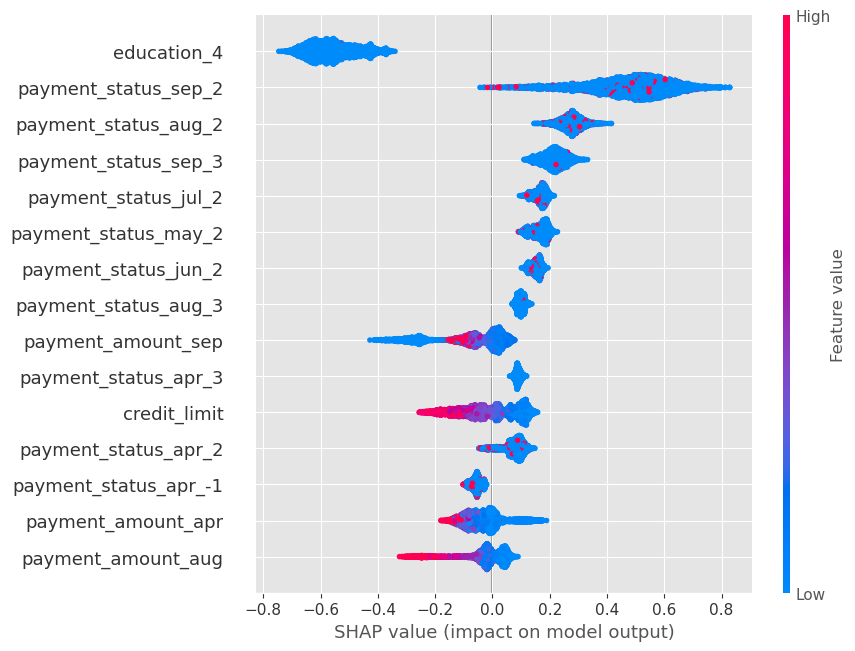

In [312]:
shap.plots.beeswarm(
    shap_values,
    max_display=15,
    group_remaining_features=False
)

In [320]:
df.groupby("education")["default"].agg(
    clients="size",
    default_rate="mean"
)

,clients,default_rate
education,,
1,10563,0.192370
2,14019,0.237392
3,4915,0.251679
4,468,0.070513


## 10.2 Client Profile

The model assigns this client a high probability of default, and SHAP indicates which characteristics contributed most strongly to that prediction.

In [322]:
high_risk_position = np.argmax(
    score_results["probability_of_default"].values
)

score_results.iloc[high_risk_position]

actual_default                           1
probability_of_default            0.912832
credit_score                           340
score_decile              (339.999, 489.2]
risk_grade                       Very High
Name: 5145, dtype: object

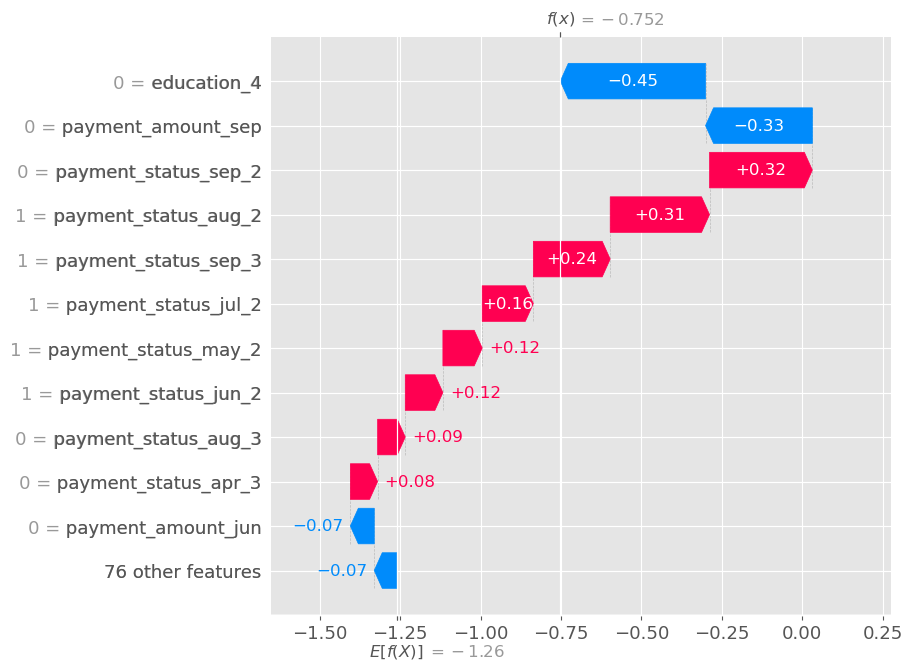

In [323]:
shap.plots.waterfall(
    shap_values[high_risk_position],
    max_display=12
)

# 11. Conclusion